# xG Model Tuning Notebook

End-to-end workflow for building, evaluating, and saving the best expected goals (xG) model. This is used in the stamina_models/xg_fatigue.ipynb file.

**Overtime is excluded** — 3-on-3 OT is a fundamentally different game; the model covers regulation only.
Any downstream use of `score_shots_v2` automatically skips OT shots.

**Contents**
1. Setup & feature engineering (regulation shots only)
2. EDA — shot distributions, goal rate by feature
3. Train / test split by game (~80/20)
4. Feature set comparison — 5-fold CV AUC & Brier
5. Hyperparameter tuning — Logistic Regression & Gradient Boosting (CV)
6. Calibration — out-of-fold isotonic; evaluate on test
7. Final evaluation on held-out test games
8. Save best model → `data/xg_model_best.pkl`

**Reloading the saved model** in any other notebook:
```python
import xg_model as xgm
xg_pipe, feat_cols = xgm.load_xg_model('data/xg_model_best.pkl')
# score_shots_v2 automatically excludes overtime
shots_scored = xgm.score_shots_v2(xg_pipe, feat_cols, events)
```


In [8]:
import sys, warnings, importlib
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    RocCurveDisplay, brier_score_loss, roc_auc_score, roc_curve, log_loss,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
import joblib
import pathlib

sys.path.insert(0, str(pathlib.Path('..').resolve()))

import utils
importlib.reload(utils)
from utils import load_events

import xg_model as xgm
importlib.reload(xgm)

events = load_events('../data/events.parquet')

GOAL_X = 89.0          # ft from centre ice
MODEL_SAVE_PATH = 'data/xg_model_best.pkl'

print(f'Events loaded: {len(events):,} rows across {events["Game"].nunique()} games.')
print(f'Event types: {events["Event"].value_counts().to_dict()}')


Events loaded: 19,200 rows across 10 games.
Event types: {'Play': 6580, 'Puck Recovery': 5360, 'Incomplete Play': 1783, 'Zone Entry': 1507, 'Dump In/Out': 1476, 'Shot': 1132, 'Takeaway': 631, 'Faceoff Win': 578, 'Penalty Taken': 95, 'Goal': 58}


In [9]:
_XG_EVENTS = {'Shot', 'Goal', 'Missed Shot'}

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build a shot-level DataFrame with all candidate predictors.
    Blocked shots are excluded — the goalie never faced them.
    Overtime shots are excluded — 3-on-3 OT is a different game.
    """
    shots = df[df['Event'].isin(_XG_EVENTS)].copy()

    x = shots['X_Coordinate'].astype(float)
    y = shots['Y_Coordinate'].astype(float)
    goal_x = np.where(x >= 0, GOAL_X, -GOAL_X)

    # ── Core geometry ──────────────────────────────────────────────────────
    shots['shot_dist_ft']  = np.sqrt((x - goal_x) ** 2 + y ** 2)
    shots['shot_angle_deg']= np.degrees(np.arctan2(np.abs(y), np.abs(goal_x - x)))
    shots['shot_dist_sq']  = shots['shot_dist_ft'] ** 2
    shots['dist_x_angle']  = shots['shot_dist_ft'] * shots['shot_angle_deg']
    shots['is_sharp_angle']= (shots['shot_angle_deg'] > 55).astype(int)
    shots['is_slot']       = (
        (shots['shot_dist_ft'] < 30) & (shots['shot_angle_deg'] < 45)
    ).astype(int)

    # ── Shot type ──────────────────────────────────────────────────────────
    shots['shot_type'] = shots['Detail_1'].fillna('Unknown').astype(str)

    # ── Strength state (skater counts) ────────────────────────────────────
    # Home_Team_Skaters / Away_Team_Skaters = skaters on ice, goalie not counted.
    # 5 = full strength, 4 = short-handed, 6 = pulled goalie (extra attacker).
    # Empty net: the DEFENDING team has pulled their goalie → defender_skaters == 6.
    home_sk = pd.to_numeric(shots['Home_Team_Skaters'], errors='coerce').fillna(5)
    away_sk = pd.to_numeric(shots['Away_Team_Skaters'], errors='coerce').fillna(5)
    is_home_team = (shots['Team'] == shots['Home_Team'])
    shots['shooter_skaters']  = np.where(is_home_team, home_sk, away_sk).astype(int)
    shots['defender_skaters'] = np.where(is_home_team, away_sk, home_sk).astype(int)
    shots['skater_advantage'] = shots['shooter_skaters'] - shots['defender_skaters']
    shots['is_power_play']    = (shots['skater_advantage'] > 0).astype(int)
    shots['is_penalty_kill']  = (shots['skater_advantage'] < 0).astype(int)
    # Empty net = defending team pulled their goalie (6 skaters attacking, no goalie)
    shots['is_empty_net']     = (shots['defender_skaters'] >= 6).astype(int)
    shots['is_3on3']          = ((shots['shooter_skaters'] == 3) &
                                  (shots['defender_skaters'] == 3)).astype(int)

    # Categorical strength label. Order matters: check 3v3/EN before advantage comparisons.
    def _strength_label(sh, de):
        if sh == 5 and de == 5: return '5v5'
        if sh == 3 and de == 3: return '3v3'
        if de >= 6:             return 'EN'   # defending team pulled goalie
        if sh > de:             return 'PP'   # 5v4, 4v3, etc.
        if sh < de:             return 'PK'   # 4v5, 3v4, etc.
        return 'other'
    shots['strength_state'] = [_strength_label(s, d)
                                for s, d in zip(shots['shooter_skaters'],
                                                shots['defender_skaters'])]

    # ── Game-state context ─────────────────────────────────────────────────
    shots['period'] = shots['Period_int'].astype(int)
    shots['clock_s'] = shots.get('Clock_s', pd.Series(600, index=shots.index))\
                            .fillna(600).astype(float)
    shots['is_overtime'] = (shots['period'] > 3).astype(int)

    # ── Exclude overtime — 3-on-3 OT is a fundamentally different game ────
    shots = shots[shots['is_overtime'] == 0].copy()

    # ── Outcome ────────────────────────────────────────────────────────────
    shots['is_goal'] = (shots['Event'] == 'Goal').astype(int)

    shots = shots.dropna(subset=['shot_dist_ft', 'shot_angle_deg'])
    return shots.reset_index(drop=True)


shots_all = engineer_features(events)
print(f'Total regulation unblocked shots: {len(shots_all):,}')
print(f'Goals: {shots_all["is_goal"].sum()}  ({shots_all["is_goal"].mean():.1%} conversion)')
print(f'\nShot type breakdown:')
print(shots_all['shot_type'].value_counts().to_string())
print(f'\nStrength state breakdown:')
print(shots_all.groupby('strength_state').agg(
    n=('is_goal','count'), goal_rate=('is_goal','mean')
).sort_values('n', ascending=False).round(3).to_string())
print(f'\nRaw skater count distribution (shooter, defender):')
print(shots_all.groupby(['shooter_skaters','defender_skaters']).size().reset_index(name='n').to_string())


Total regulation unblocked shots: 1,173
Goals: 56  (4.8% conversion)

Shot type breakdown:
shot_type
Wristshot      507
Snapshot       444
Slapshot       116
Deflection      63
Fan             32
Wrap Around      6
Bat              3
Poke             2

Strength state breakdown:
                  n  goal_rate
strength_state                
5v5             920      0.038
PP              224      0.085
PK               18      0.056
other             8      0.000
EN                3      0.333

Raw skater count distribution (shooter, defender):
   shooter_skaters  defender_skaters    n
0                4                 3    4
1                4                 4    8
2                4                 5   18
3                5                 3   11
4                5                 4  176
5                5                 5  920
6                5                 6    3
7                6                 4    4
8                6                 5   29


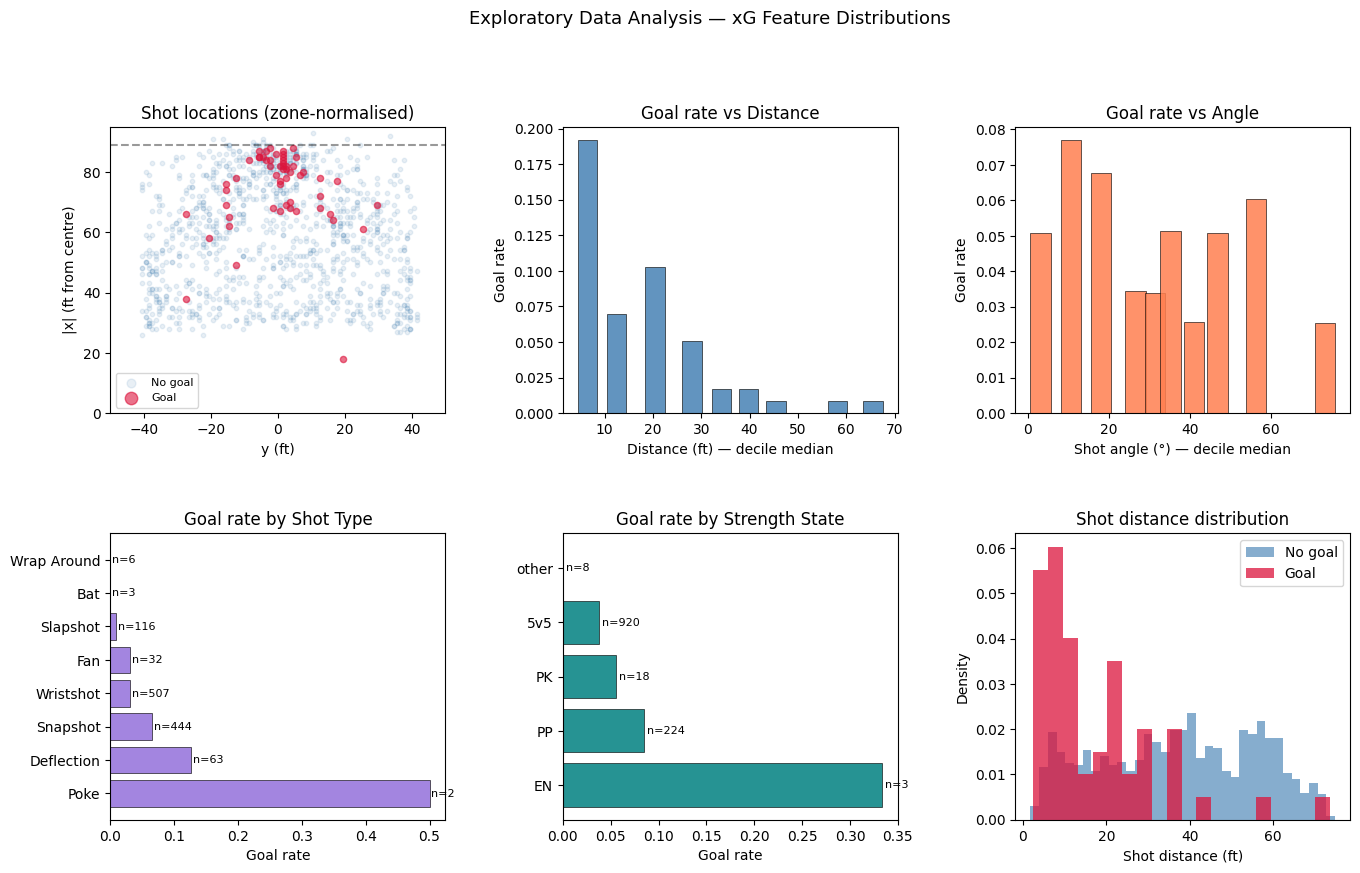

In [10]:
fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# 1. Shot chart (top-down)
ax0 = fig.add_subplot(gs[0, 0])
goals  = shots_all[shots_all['is_goal'] == 1]
no_gls = shots_all[shots_all['is_goal'] == 0]
# Flip negative-zone shots to the same side
x_plot = shots_all['X_Coordinate'].abs()
y_plot = shots_all['Y_Coordinate']
ax0.scatter(y_plot[shots_all['is_goal']==0], x_plot[shots_all['is_goal']==0],
            alpha=0.12, s=10, color='steelblue', label='No goal')
ax0.scatter(y_plot[shots_all['is_goal']==1], x_plot[shots_all['is_goal']==1],
            alpha=0.6,  s=20, color='crimson', label='Goal')
ax0.axhline(GOAL_X, color='k', lw=1.5, ls='--', alpha=0.4)
ax0.set_xlim(-50, 50); ax0.set_ylim(0, 95)
ax0.set_xlabel('y (ft)'); ax0.set_ylabel('|x| (ft from centre)')
ax0.set_title('Shot locations (zone-normalised)'); ax0.legend(fontsize=8, markerscale=2)

# 2. Goal rate by distance decile
ax1 = fig.add_subplot(gs[0, 1])
shots_all['dist_decile'] = pd.qcut(shots_all['shot_dist_ft'], 10, labels=False)
gr_dist = shots_all.groupby('dist_decile').agg(
    goal_rate=('is_goal','mean'), med_dist=('shot_dist_ft','median'), n=('is_goal','count')
).reset_index()
ax1.bar(gr_dist['med_dist'], gr_dist['goal_rate'], width=4,
        color='steelblue', edgecolor='k', lw=0.5, alpha=0.85)
ax1.set_xlabel('Distance (ft) — decile median'); ax1.set_ylabel('Goal rate')
ax1.set_title('Goal rate vs Distance')

# 3. Goal rate by angle decile
ax2 = fig.add_subplot(gs[0, 2])
shots_all['angle_decile'] = pd.qcut(shots_all['shot_angle_deg'], 10, labels=False)
gr_ang = shots_all.groupby('angle_decile').agg(
    goal_rate=('is_goal','mean'), med_ang=('shot_angle_deg','median'), n=('is_goal','count')
).reset_index()
ax2.bar(gr_ang['med_ang'], gr_ang['goal_rate'], width=5,
        color='coral', edgecolor='k', lw=0.5, alpha=0.85)
ax2.set_xlabel('Shot angle (°) — decile median'); ax2.set_ylabel('Goal rate')
ax2.set_title('Goal rate vs Angle')

# 4. Goal rate by shot type
ax3 = fig.add_subplot(gs[1, 0])
gr_type = shots_all.groupby('shot_type').agg(
    goal_rate=('is_goal','mean'), n=('is_goal','count')
).sort_values('goal_rate', ascending=False).reset_index()
ax3.barh(gr_type['shot_type'], gr_type['goal_rate'],
         color='mediumpurple', edgecolor='k', lw=0.5, alpha=0.85)
for _, row in gr_type.iterrows():
    ax3.text(row['goal_rate'] + 0.003, row.name, f'n={int(row["n"])}', va='center', fontsize=8)
ax3.set_xlabel('Goal rate'); ax3.set_title('Goal rate by Shot Type')

# 5. Goal rate by strength state
ax4 = fig.add_subplot(gs[1, 1])
gr_str = shots_all.groupby('strength_state').agg(
    goal_rate=('is_goal','mean'), n=('is_goal','count')
).sort_values('goal_rate', ascending=False).reset_index()
ax4.barh(gr_str['strength_state'], gr_str['goal_rate'],
         color='teal', edgecolor='k', lw=0.5, alpha=0.85)
for _, row in gr_str.iterrows():
    ax4.text(row['goal_rate'] + 0.003, row.name,
             f'n={int(row["n"])}', va='center', fontsize=8)
ax4.set_xlabel('Goal rate'); ax4.set_title('Goal rate by Strength State')

# 6. Shot distance histogram
ax5 = fig.add_subplot(gs[1, 2])
ax5.hist(shots_all[shots_all['is_goal']==0]['shot_dist_ft'], bins=35,
         alpha=0.65, color='steelblue', density=True, label='No goal')
ax5.hist(shots_all[shots_all['is_goal']==1]['shot_dist_ft'], bins=20,
         alpha=0.75, color='crimson', density=True, label='Goal')
ax5.set_xlabel('Shot distance (ft)'); ax5.set_ylabel('Density')
ax5.set_title('Shot distance distribution'); ax5.legend()

plt.suptitle('Exploratory Data Analysis — xG Feature Distributions', fontsize=13, y=1.01)
plt.show()


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# Split by GAME — not by row.
# No separate validation split: 5-fold CV within training handles model selection
# and hyperparameter tuning. Test games are a true held-out evaluation only.
# With 10 games (2 OT dropped from training; regulation only): train≈8, test≈2
# ─────────────────────────────────────────────────────────────────────────────
rng = np.random.default_rng(42)
all_games = sorted(shots_all['Game'].unique())
shuffled  = rng.permutation(all_games).tolist()

n_total = len(shuffled)
n_test  = max(2, round(n_total * 0.2))
n_train = n_total - n_test

test_games  = shuffled[:n_test]
train_games = shuffled[n_test:]

print(f'Games — Train: {len(train_games)}  Test: {len(test_games)}')
print(f'  Train: {train_games}')
print(f'  Test : {test_games}')

df_train = shots_all[shots_all['Game'].isin(train_games)].copy()
df_test  = shots_all[shots_all['Game'].isin(test_games)].copy()

for split, df in [('Train', df_train), ('Test', df_test)]:
    print(f'  {split}: {len(df):,} shots, {df["is_goal"].sum()} goals ({df["is_goal"].mean():.1%})')


Games — Train: 8  Test: 2
  Train: ['2025-10-11 Team D @ Team A', '2025-11-16 Team K @ Team H', '2025-10-24 Team D @ Team E', '2025-10-24 Team A @ Team B', '2025-10-28 Team A @ Team C', '2025-11-28 Team K @ Team J', '2025-10-17 Team L @ Team F', '2025-11-19 Team K @ Team I']
  Test : ['2025-10-29 Team L @ Team G', '2025-11-02 Team A @ Team D']
  Train: 962 shots, 42 goals (4.4%)
  Test: 211 shots, 14 goals (6.6%)


Train: 962 shots | 5v5=766  PP=172
Test: 211 shots | 5v5=154  PP=52

minimal         CV AUC=0.7932±0.1188  CV Brier=0.0400±0.0029
standard        CV AUC=0.7870±0.1128  CV Brier=0.0400±0.0030
nonlinear       CV AUC=0.7856±0.1120  CV Brier=0.0400±0.0029
interaction     CV AUC=0.7839±0.1118  CV Brier=0.0400±0.0029
full            CV AUC=0.7766±0.1059  CV Brier=0.0397±0.0025
with_strength   CV AUC=0.7847±0.1133  CV Brier=0.0403±0.0038


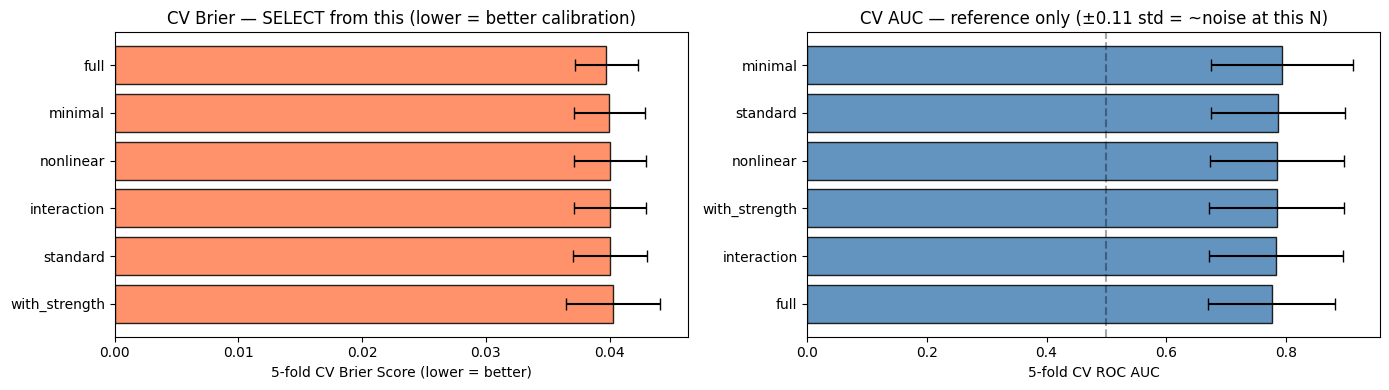


Best by CV Brier (selected): full
Best by CV AUC  (reference): minimal  ← high variance at N~960, ignore
               cv_auc_mean  cv_auc_std  cv_brier_mean  cv_brier_std
minimal             0.7932      0.1188         0.0400        0.0029
standard            0.7870      0.1128         0.0400        0.0030
nonlinear           0.7856      0.1120         0.0400        0.0029
interaction         0.7839      0.1118         0.0400        0.0029
full                0.7766      0.1059         0.0397        0.0025
with_strength       0.7847      0.1133         0.0403        0.0038


In [12]:
# ── Sanity check: strength-state coverage per split ──────────────────────────
for split_name, df in [('Train', df_train), ('Test', df_test)]:
    pp = (df['is_power_play'] == 1).sum()
    ev = (df['strength_state'] == '5v5').sum()
    print(f'{split_name}: {len(df)} shots | 5v5={ev}  PP={pp}')
print()

FEATURE_SETS = {
    'minimal':    {'num': ['shot_dist_ft'],
                   'cat': [], 'bin': []},
    'standard':   {'num': ['shot_dist_ft', 'shot_angle_deg'],
                   'cat': ['shot_type'], 'bin': []},
    'nonlinear':  {'num': ['shot_dist_ft', 'shot_angle_deg', 'shot_dist_sq'],
                   'cat': ['shot_type'], 'bin': []},
    'interaction':{'num': ['shot_dist_ft', 'shot_angle_deg', 'shot_dist_sq', 'dist_x_angle'],
                   'cat': ['shot_type'], 'bin': []},
    'full':       {'num': ['shot_dist_ft', 'shot_angle_deg', 'shot_dist_sq', 'dist_x_angle'],
                   'cat': ['shot_type'],
                   'bin': ['is_sharp_angle', 'is_slot', 'period']},
    'with_strength': {'num': ['shot_dist_ft', 'shot_angle_deg', 'shot_dist_sq',
                               'dist_x_angle', 'skater_advantage', 'shooter_skaters'],
                      'cat': ['shot_type', 'strength_state'],
                      'bin': ['is_sharp_angle', 'is_slot', 'is_power_play',
                               'is_penalty_kill', 'is_empty_net']},
}

y_train = df_train['is_goal'].values
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fs_results = {}
for name, feat in FEATURE_SETS.items():
    num_cols = feat['num']
    cat_cols = feat['cat']
    bin_cols = feat['bin']

    transformers = [('num', StandardScaler(), num_cols)]
    if cat_cols:
        transformers.append(('cat', OneHotEncoder(handle_unknown='ignore',
                                                   sparse_output=False), cat_cols))
    if bin_cols:
        transformers.append(('bin', 'passthrough', bin_cols))

    X_tr = df_train[num_cols + cat_cols + bin_cols]

    pipe_proto = Pipeline([('pre', ColumnTransformer(transformers)),
                            ('lr', LogisticRegression(C=1.0, max_iter=1000))])
    cv_auc   = cross_val_score(pipe_proto, X_tr, y_train, cv=skf, scoring='roc_auc')
    cv_brier = cross_val_score(pipe_proto, X_tr, y_train, cv=skf, scoring='neg_brier_score')
    fs_results[name] = {
        'cv_auc_mean':   cv_auc.mean(),
        'cv_auc_std':    cv_auc.std(),
        'cv_brier_mean': -cv_brier.mean(),
        'cv_brier_std':  cv_brier.std(),
    }
    print(f'{name:<14s}  CV AUC={cv_auc.mean():.4f}±{cv_auc.std():.4f}'
          f'  CV Brier={-cv_brier.mean():.4f}±{cv_brier.std():.4f}')

fs_df = pd.DataFrame(fs_results).T

# ── Selection rationale ───────────────────────────────────────────────────────
# With ~960 shots, CV AUC std is ±0.11 — any AUC difference < 0.05 is pure noise.
# We use Brier score to select the feature set because:
#   1. xG is a probability estimate used in sums, not a ranking — calibration matters.
#   2. Brier has far lower variance (std ±0.003) at this sample size.
#   3. Domain knowledge confirms distance + angle + shot type are all meaningful.
# AUC is shown for reference only.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fs_brier = fs_df.sort_values('cv_brier_mean', ascending=False)  # lower is better → sort desc for barh
fs_auc   = fs_df.sort_values('cv_auc_mean',   ascending=True)

axes[0].barh(list(fs_brier.index), fs_brier['cv_brier_mean'],
             xerr=fs_brier['cv_brier_std'], color='coral', edgecolor='k', alpha=0.85, capsize=4)
axes[0].set_xlabel('5-fold CV Brier Score (lower = better)')
axes[0].set_title('CV Brier — SELECT from this (lower = better calibration)')

axes[1].barh(list(fs_auc.index), fs_auc['cv_auc_mean'],
             xerr=fs_auc['cv_auc_std'], color='steelblue', edgecolor='k', alpha=0.85, capsize=4)
axes[1].axvline(0.5, color='k', ls='--', alpha=0.35)
axes[1].set_xlabel('5-fold CV ROC AUC')
axes[1].set_title('CV AUC — reference only (±0.11 std = ~noise at this N)')
plt.tight_layout(); plt.show()

# Pick by Brier — xG is a probability estimate, calibration quality is what matters
best_feature_set = fs_df['cv_brier_mean'].idxmin()
print(f'\nBest by CV Brier (selected): {best_feature_set}')
print(f'Best by CV AUC  (reference): {fs_df["cv_auc_mean"].idxmax()}  ← high variance at N~960, ignore')
print(fs_df[['cv_auc_mean','cv_auc_std','cv_brier_mean','cv_brier_std']].round(4).to_string())


=== Logistic Regression — C sweep (5-fold CV) ===
  C=0.001   CV AUC=0.7945
  C=0.01    CV AUC=0.7900
  C=0.1     CV AUC=0.7856
  C=0.5     CV AUC=0.7797
  C=1.0     CV AUC=0.7766
  C=2.0     CV AUC=0.7742
  C=5.0     CV AUC=0.7633
  C=10.0    CV AUC=0.7569

Best C = 0.001

=== Gradient Boosting — grid sweep (5-fold CV) ===
  n=50 d=2 lr=0.05  CV=0.7740
  n=50 d=2 lr=0.1  CV=0.7498
  n=50 d=3 lr=0.05  CV=0.7727
  n=50 d=3 lr=0.1  CV=0.7665
  n=50 d=4 lr=0.05  CV=0.7701
  n=50 d=4 lr=0.1  CV=0.7605
  n=100 d=2 lr=0.05  CV=0.7581
  n=100 d=2 lr=0.1  CV=0.7505
  n=100 d=3 lr=0.05  CV=0.7733
  n=100 d=3 lr=0.1  CV=0.7614
  n=100 d=4 lr=0.05  CV=0.7585
  n=100 d=4 lr=0.1  CV=0.7509
  n=200 d=2 lr=0.05  CV=0.7629
  n=200 d=2 lr=0.1  CV=0.7447
  n=200 d=3 lr=0.05  CV=0.7567
  n=200 d=3 lr=0.1  CV=0.7639
  n=200 d=4 lr=0.05  CV=0.7376
  n=200 d=4 lr=0.1  CV=0.7242

Best GB: n_estimators=50  max_depth=2  lr=0.05


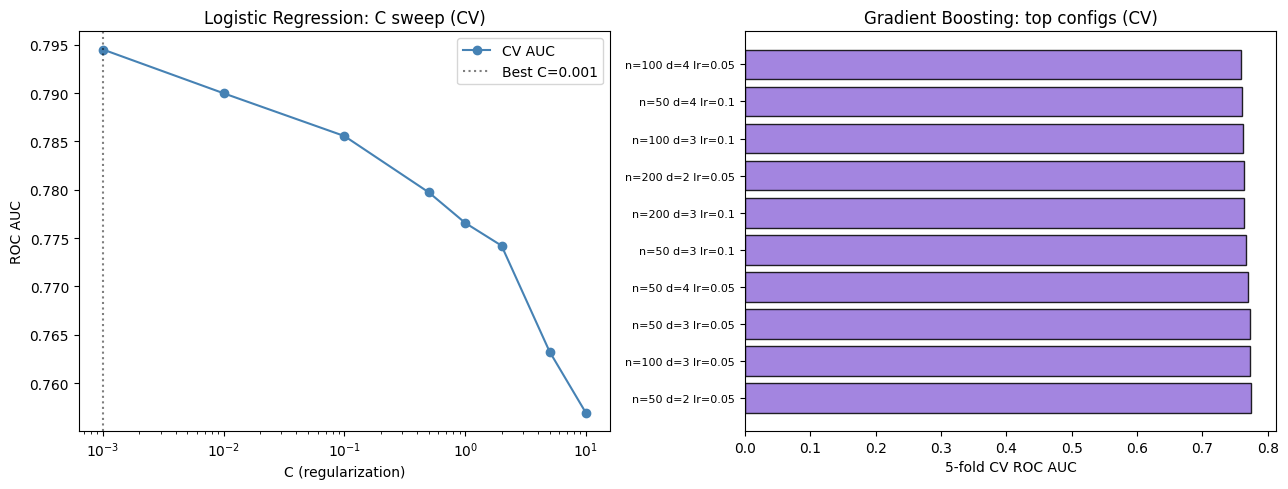

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# Hyperparameter tuning on the best feature set using 5-fold CV only.
# ─────────────────────────────────────────────────────────────────────────────
TUNE_FEATS = FEATURE_SETS.get(best_feature_set, FEATURE_SETS['full'])
num_cols = TUNE_FEATS['num']
cat_cols = TUNE_FEATS['cat']
bin_cols = TUNE_FEATS['bin']
all_feats = num_cols + cat_cols + bin_cols

transformers = [('num', StandardScaler(), num_cols)]
if cat_cols:
    transformers.append(('cat', OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False), cat_cols))
if bin_cols:
    transformers.append(('bin', 'passthrough', bin_cols))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_train_feats = df_train[all_feats]
X_test_feats  = df_test[all_feats]
y_test        = df_test['is_goal'].values

# ── Logistic Regression — vary C ─────────────────────────────────────────────
print('=== Logistic Regression — C sweep (5-fold CV) ===')
C_vals = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
lr_results = []
for C in C_vals:
    pipe = Pipeline([('pre', ColumnTransformer(transformers)),
                     ('lr', LogisticRegression(C=C, max_iter=1000))])
    cv_auc = cross_val_score(pipe, X_train_feats, y_train, cv=skf, scoring='roc_auc').mean()
    lr_results.append({'C': C, 'cv_auc': cv_auc})
    print(f'  C={C:<6}  CV AUC={cv_auc:.4f}')

lr_df  = pd.DataFrame(lr_results)
best_C = lr_df.loc[lr_df['cv_auc'].idxmax(), 'C']
print(f'\nBest C = {best_C}')

# ── Gradient Boosting — vary n_estimators, max_depth, learning_rate ──────────
print('\n=== Gradient Boosting — grid sweep (5-fold CV) ===')
gb_results = []
for n_est in [50, 100, 200]:
    for depth in [2, 3, 4]:
        for lr_rate in [0.05, 0.1]:
            pipe_gb = Pipeline([
                ('pre', ColumnTransformer(transformers)),
                ('gb', GradientBoostingClassifier(
                    n_estimators=n_est, max_depth=depth,
                    learning_rate=lr_rate, random_state=42,
                )),
            ])
            cv_auc = cross_val_score(pipe_gb, X_train_feats, y_train,
                                     cv=skf, scoring='roc_auc').mean()
            gb_results.append({
                'n_estimators': n_est, 'max_depth': depth, 'lr': lr_rate, 'cv_auc': cv_auc,
            })
            print(f'  n={n_est} d={depth} lr={lr_rate}  CV={cv_auc:.4f}')

gb_df   = pd.DataFrame(gb_results)
best_gb = gb_df.loc[gb_df['cv_auc'].idxmax()]
print(f'\nBest GB: n_estimators={best_gb.n_estimators:.0f}  '
      f'max_depth={best_gb.max_depth:.0f}  lr={best_gb.lr}')

# ── Summary plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].semilogx(lr_df['C'], lr_df['cv_auc'], 'o-', color='steelblue', label='CV AUC')
axes[0].axvline(best_C, color='k', ls=':', alpha=0.5, label=f'Best C={best_C}')
axes[0].set_xlabel('C (regularization)'); axes[0].set_ylabel('ROC AUC')
axes[0].set_title('Logistic Regression: C sweep (CV)'); axes[0].legend()

sorted_gb = gb_df.sort_values('cv_auc', ascending=False).head(10)
axes[1].barh(range(len(sorted_gb)),
             sorted_gb['cv_auc'], color='mediumpurple', edgecolor='k', alpha=0.85)
lbl = [f'n={r.n_estimators:.0f} d={r.max_depth:.0f} lr={r.lr}'
       for _, r in sorted_gb.iterrows()]
axes[1].set_yticks(range(len(sorted_gb))); axes[1].set_yticklabels(lbl, fontsize=8)
axes[1].set_xlabel('5-fold CV ROC AUC')
axes[1].set_title('Gradient Boosting: top configs (CV)')
plt.tight_layout(); plt.show()


LogReg (best C)            AUC=0.8510  Brier=0.0619  LogLoss=0.2424
GradBoost                  AUC=0.8011  Brier=0.0632  LogLoss=0.2241
GradBoost+Isotonic         AUC=0.8051  Brier=0.0569  LogLoss=0.2032


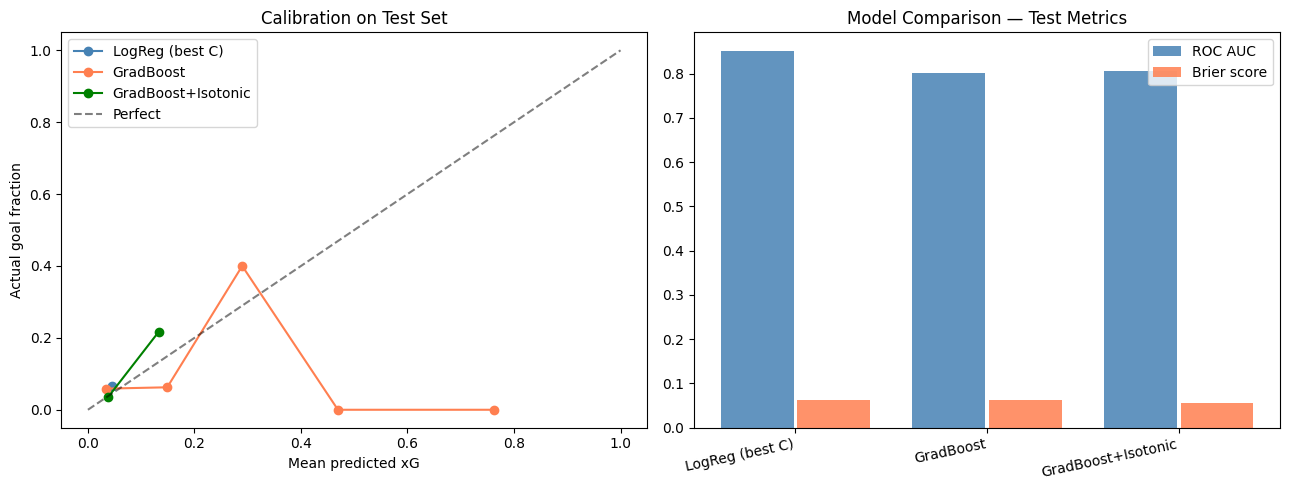

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# Build the two best pipelines (LR + GB) on the full training set.
# Isotonic calibration is fitted on out-of-fold (OOF) training predictions
# via cross_val_predict — this avoids needing a separate validation game.
# All three final models are evaluated on the held-out test set.
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import cross_val_predict
from sklearn.isotonic import IsotonicRegression

# Best LR
best_lr_pipe = Pipeline([
    ('pre', ColumnTransformer(transformers)),
    ('lr', LogisticRegression(C=best_C, max_iter=1000)),
])
best_lr_pipe.fit(X_train_feats, y_train)

# Best GB
best_gb_pipe = Pipeline([
    ('pre', ColumnTransformer(transformers)),
    ('gb', GradientBoostingClassifier(
        n_estimators=int(best_gb.n_estimators),
        max_depth=int(best_gb.max_depth),
        learning_rate=float(best_gb.lr),
        random_state=42,
    )),
])
best_gb_pipe.fit(X_train_feats, y_train)

# OOF isotonic calibration — fit on CV out-of-fold predictions, not on training labels directly
oof_probs_gb = cross_val_predict(
    Pipeline([('pre', ColumnTransformer(transformers)),
              ('gb', GradientBoostingClassifier(
                  n_estimators=int(best_gb.n_estimators),
                  max_depth=int(best_gb.max_depth),
                  learning_rate=float(best_gb.lr),
                  random_state=42))]),
    X_train_feats, y_train, cv=skf, method='predict_proba',
)[:, 1]
iso_cal = IsotonicRegression(out_of_bounds='clip')
iso_cal.fit(oof_probs_gb, y_train)

# ── Evaluate all three on the held-out test set ───────────────────────────────
prob_lr_test     = best_lr_pipe.predict_proba(X_test_feats)[:, 1]
prob_gb_test     = best_gb_pipe.predict_proba(X_test_feats)[:, 1]
prob_cal_gb_test = iso_cal.predict(prob_gb_test)

models_for_cal = [
    ('LogReg (best C)',    prob_lr_test,     'steelblue'),
    ('GradBoost',          prob_gb_test,     'coral'),
    ('GradBoost+Isotonic', prob_cal_gb_test, 'green'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, probs, color in models_for_cal:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=8, strategy='uniform')
    axes[0].plot(mean_pred, frac_pos, 'o-', label=name, color=color)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
axes[0].set_xlabel('Mean predicted xG'); axes[0].set_ylabel('Actual goal fraction')
axes[0].set_title('Calibration on Test Set'); axes[0].legend()

metrics = []
for name, probs, _ in models_for_cal:
    auc_v  = roc_auc_score(y_test, probs)
    brier  = brier_score_loss(y_test, probs)
    ll     = log_loss(y_test, probs)
    metrics.append({'Model': name, 'Test AUC': auc_v, 'Brier': brier, 'LogLoss': ll})
    print(f'{name:<25s}  AUC={auc_v:.4f}  Brier={brier:.4f}  LogLoss={ll:.4f}')

met_df = pd.DataFrame(metrics)
x_pos = np.arange(len(met_df))
axes[1].bar(x_pos - 0.2, met_df['Test AUC'], 0.38, label='ROC AUC', color='steelblue', alpha=0.85)
axes[1].bar(x_pos + 0.2, met_df['Brier'],    0.38, label='Brier score', color='coral', alpha=0.85)
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(met_df['Model'], rotation=12, ha='right')
axes[1].set_title('Model Comparison — Test Metrics'); axes[1].legend()
plt.tight_layout(); plt.show()


Best model by Brier: GradBoost+Isotonic
Test set: 211 shots, 14 goals (6.6%)
Test AUC     = 0.8051
Test Brier   = 0.0569
Test LogLoss = 0.2032


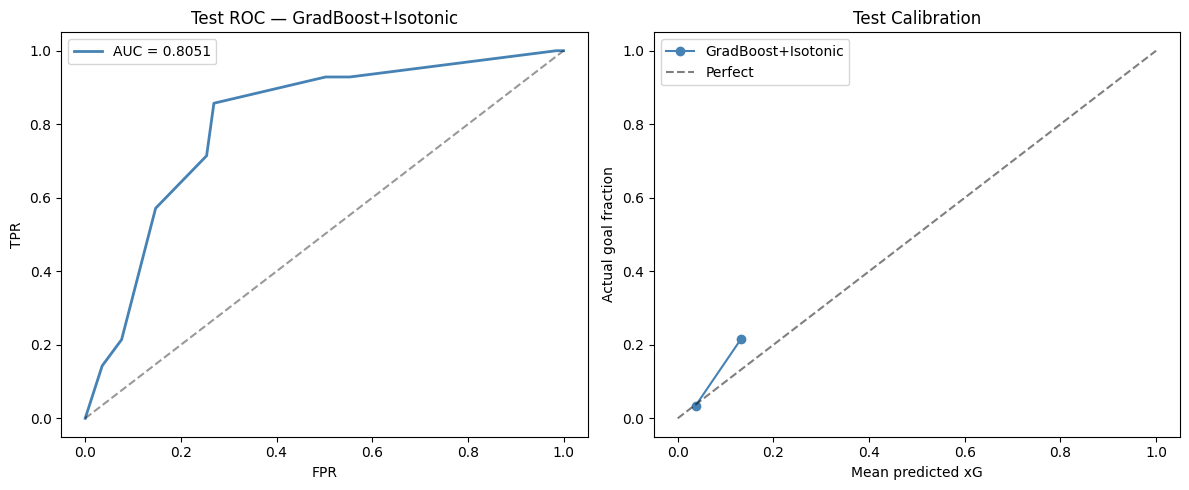

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Pick the best model by Brier score (calibration quality matters for xG sums)
# and display its ROC curve + calibration on the test set.
# ─────────────────────────────────────────────────────────────────────────────
best_idx        = met_df['Brier'].idxmin()
best_model_name = met_df.loc[best_idx, 'Model']
auc_test        = met_df.loc[best_idx, 'Test AUC']
brier_test      = met_df.loc[best_idx, 'Brier']
ll_test         = met_df.loc[best_idx, 'LogLoss']
print(f'Best model by Brier: {best_model_name}')
print(f'Test set: {len(y_test):,} shots, {int(y_test.sum())} goals ({y_test.mean():.1%})')
print(f'Test AUC     = {auc_test:.4f}')
print(f'Test Brier   = {brier_test:.4f}')
print(f'Test LogLoss = {ll_test:.4f}')

def predict_with_model(name, X):
    if name == 'GradBoost+Isotonic':
        return iso_cal.predict(best_gb_pipe.predict_proba(X)[:, 1])
    elif name == 'GradBoost':
        return best_gb_pipe.predict_proba(X)[:, 1]
    else:
        return best_lr_pipe.predict_proba(X)[:, 1]

prob_test = predict_with_model(best_model_name, X_test_feats)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fpr, tpr, _ = roc_curve(y_test, prob_test)
axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc_test:.4f}')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title(f'Test ROC — {best_model_name}'); axes[0].legend()

frac_pos_t, mean_pred_t = calibration_curve(y_test, prob_test, n_bins=8, strategy='uniform')
axes[1].plot(mean_pred_t, frac_pos_t, 'o-', color='steelblue', label=best_model_name)
axes[1].plot([0,1],[0,1],'k--', alpha=0.5, label='Perfect')
axes[1].set_xlabel('Mean predicted xG'); axes[1].set_ylabel('Actual goal fraction')
axes[1].set_title('Test Calibration'); axes[1].legend()
plt.tight_layout(); plt.show()


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# Retrain the best architecture on ALL available regulation data,
# then save with joblib.  The saved file is what every other notebook loads.
# ─────────────────────────────────────────────────────────────────────────────
shots_all_clean = shots_all.dropna(subset=all_feats + ['is_goal'])
X_all = shots_all_clean[all_feats]
y_all = shots_all_clean['is_goal'].values

if 'GradBoost' in best_model_name:
    final_estimator = GradientBoostingClassifier(
        n_estimators=int(best_gb.n_estimators),
        max_depth=int(best_gb.max_depth),
        learning_rate=float(best_gb.lr),
        random_state=42,
    )
    final_pipe = Pipeline([('pre', ColumnTransformer(transformers)),
                            ('model', final_estimator)])
else:
    final_estimator = LogisticRegression(C=best_C, max_iter=1000)
    final_pipe = Pipeline([('pre', ColumnTransformer(transformers)),
                            ('model', final_estimator)])

final_pipe.fit(X_all, y_all)

# Calibrate with 5-fold Platt scaling on all data
final_cal = CalibratedClassifierCV(final_pipe, cv=5, method='sigmoid')
final_cal.fit(X_all, y_all)

save_path = Path(MODEL_SAVE_PATH)
save_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump({
    'pipe': final_cal,
    'features': all_feats,
    'num_cols': num_cols,
    'cat_cols': cat_cols,
    'bin_cols': bin_cols,
    'best_model_name': best_model_name,
    'test_auc': float(auc_test),
    'test_brier': float(brier_test),
    'ot_excluded': True,   # model covers regulation only
}, save_path, compress=3)

print(f'Saved: {save_path}  ({save_path.stat().st_size / 1024:.1f} KB)')
print(f'Model   : {best_model_name}')
print(f'Features: {all_feats}')
print(f'Test AUC={auc_test:.4f}  Test Brier={brier_test:.4f}')
print(f'OT excluded: True — score_shots_v2 will skip overtime rows automatically')
print()
print('>>> To reload in any notebook:')
print("    import xg_model as xgm")
print("    xg_pipe, feat_cols = xgm.load_xg_model('data/xg_model_best.pkl')")


Saved: data/xg_model_best.pkl  (76.4 KB)
Model   : GradBoost+Isotonic
Features: ['shot_dist_ft', 'shot_angle_deg', 'shot_dist_sq', 'dist_x_angle', 'shot_type', 'is_sharp_angle', 'is_slot', 'period']
Test AUC=0.8051  Test Brier=0.0569
OT excluded: True — score_shots_v2 will skip overtime rows automatically

>>> To reload in any notebook:
    import xg_model as xgm
    xg_pipe, feat_cols = xgm.load_xg_model('data/xg_model_best.pkl')


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Quick verify: reload from disk and check predictions match.
# ─────────────────────────────────────────────────────────────────────────────
import xg_model as xgm
importlib.reload(xgm)

loaded_pipe, loaded_feats = xgm.load_xg_model(MODEL_SAVE_PATH)
print(f'Loaded features: {loaded_feats}')

# Score a few test shots
test_sample = df_test[loaded_feats].head(5)
probs_reload = loaded_pipe.predict_proba(test_sample)[:, 1]
probs_orig   = final_cal.predict_proba(test_sample)[:, 1]
print('Sample predictions (reloaded vs original):')
for r, o in zip(probs_reload, probs_orig):
    print(f'  reloaded={r:.4f}  original={o:.4f}')

# Full-dataset scoring via helper
shots_scored = xgm.score_shots_v2(loaded_pipe, loaded_feats, events)
print(f'\nscore_shots_v2 produced {len(shots_scored):,} rows')
print(f'Mean xG = {shots_scored["xg"].mean():.4f}  '
      f'Total xG = {shots_scored["xg"].sum():.1f}')


Loaded xG model from data/xg_model_best.pkl
  Model  : GradBoost+Isotonic
  Test AUC: 0.8051
  OT excluded: True
  Features: ['shot_dist_ft', 'shot_angle_deg', 'shot_dist_sq', 'dist_x_angle', 'shot_type', 'is_sharp_angle', 'is_slot', 'period']
Loaded features: ['shot_dist_ft', 'shot_angle_deg', 'shot_dist_sq', 'dist_x_angle', 'shot_type', 'is_sharp_angle', 'is_slot', 'period']
Sample predictions (reloaded vs original):
  reloaded=0.0229  original=0.0229
  reloaded=0.0236  original=0.0236
  reloaded=0.0229  original=0.0229
  reloaded=0.0593  original=0.0593
  reloaded=0.0598  original=0.0598

score_shots_v2 produced 1,173 rows
Mean xG = 0.0485  Total xG = 56.9
